# EDA — bus dataset
Green route (17), single vehicle: the one bus with the most labeled rows spanning >=2 days.
Follows `plan/03_eda/01_eda_spec.md` sections E1-E10 (v2: whole-service-day split; target outliers dropped from train only; constants checked within train).

## E1 — Load

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from mc_common import load_features, save_model_ready, load_model_ready, iqr_fences, high_corr_pairs, prune_correlated

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

DS = "bus"
df, schema = load_features(DS)
features = list(schema["features"])
meta = list(schema["meta"])
target = schema["target"]

print("shape:", df.shape)
print("target:", target)
print("n features:", len(features))
print("n meta:", len(meta))
print(df.dtypes)


shape: (23992, 50)
target: delay_s
n features: 41
n meta: 8
t_local                 datetime64[ns]
date                               str
route_name                         str
route_id                         int64
vehicle_id                       int64
route_stop_id                    int64
split                              str
cv_group                           str
eta_s                          float64
eta_delta_s                    float64
eta_prev_missing                 int64
eta_frozen_polls               float64
dist_to_stop_m                 float64
stops_ahead                      int64
planned_s_ahead                  int64
since_last_arrival_s           float64
planned_remaining_s            float64
vehicle_speed                  float64
speed_mean_2min                float64
stationary_s                   float64
stale_gps                        int64
vehicle_lat                    float64
vehicle_lon                    float64
n_buses_active                   int64
hour

In [2]:
df.head()


,t_local,date,route_name,route_id,vehicle_id,route_stop_id,split,cv_group,eta_s,eta_delta_s,eta_prev_missing,eta_frozen_polls,dist_to_stop_m,stops_ahead,planned_s_ahead,since_last_arrival_s,planned_remaining_s,vehicle_speed,speed_mean_2min,stationary_s,stale_gps,vehicle_lat,vehicle_lon,n_buses_active,hour,minute_of_day,tod_sin,tod_cos,stop_lat,stop_lon,stop_rank_frac,stop_planned_dwell_s,temp_f,apparent_temp_f,rel_humidity,precip_in,rain_in,cloud_cover,wind_mph,wind_gust_mph,precip_prev_1h,is_raining,wx_clear,wx_cloudy,wx_drizzle,stop_emb_0,stop_emb_1,stop_emb_2,stop_emb_3,delay_s
0,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,210,test,2026-03-09_09,860.0,856.0,0,0.0,159.186219,10,876,30.000153,845.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.786130,-84.398800,0.6,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,-0.697699,1.048197,0.817457,1.696033,591.128309
1,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,195,test,2026-03-09_09,240.0,-20.0,0,0.0,672.788835,4,256,30.000153,225.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.780346,-84.399230,0.0,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,1.928625,1.445193,0.893827,-2.049272,60.003377
2,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,209,test,2026-03-09_09,547.0,-20.0,0,0.0,762.895796,9,563,30.000153,532.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.786368,-84.405321,0.5,180,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,1.676366,-0.179440,-0.513319,0.441757,700.287221
3,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,211,test,2026-03-09_09,14.0,-20.0,0,0.0,138.435671,1,30,30.000153,0.000000,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.786282,-84.395591,0.7,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,0.044664,0.379566,1.569232,-0.822362,16.000415
4,2026-03-09 11:02:20.938735,2026-03-09,Green,17,3,196,test,2026-03-09_09,281.0,-20.0,0,0.0,892.226474,5,297,30.000153,266.999847,25.0,12.5,0.0,0,33.78616,-84.39708,2,11,662,0.248972,-0.968511,33.778360,-84.399560,0.1,0,64.5,66.3,84,0.0,0.0,100,3.1,9.8,0.0,0,0,1,0,0.758628,-1.182060,0.014804,-1.519773,79.003680


## E2 — Data quality

In [3]:
n_null_features = df[features].isna().sum()
n_null_target = df[target].isna().sum()
print("null counts in features (nonzero only):")
print(n_null_features[n_null_features > 0])
print("null count in target:", n_null_target)
assert df[features + [target]].isna().sum().sum() == 0, "unexpected nulls in features/target"
print("OK: 0 nulls in features + target")


null counts in features (nonzero only):
Series([], dtype: int64)
null count in target: 0
OK: 0 nulls in features + target


In [4]:
const_features = [c for c in features if df[c].nunique(dropna=False) <= 1]
print("constant features (whole dataset):", const_features)

dup_count = df.duplicated().sum()
print("exact duplicate rows:", dup_count)

print()
print("split sizes:")
print(df[schema["split_col"]].value_counts())
print()
print("cv_group sizes (train tuning groups; date+3h block for bus, per v2 spec):")
print(df[schema["group_col"]].value_counts().sort_index())


constant features (whole dataset): []
exact duplicate rows: 0

split sizes:
split
train    16456
test      7536
Name: count, dtype: int64

cv_group sizes (train tuning groups; date+3h block for bus, per v2 spec):
cv_group
2026-03-09_09     789
2026-03-09_12    3661
2026-03-09_15    3086
2026-03-10_09    1443
2026-03-10_12    2292
2026-03-10_15    5064
2026-03-10_18    6834
2026-03-10_21     823
Name: count, dtype: int64


In [5]:
print("rows per day (and split):")
print(df.groupby(schema["split_col"])["date"].value_counts().sort_index())
print()
print("rows per vehicle:")
print(df["vehicle_id"].value_counts())
print()
print("rows per route:")
print(df["route_name"].value_counts())


rows per day (and split):
split  date      
test   2026-03-09     7536
train  2026-03-10    16456
Name: count, dtype: int64

rows per vehicle:
vehicle_id
3    23992
Name: count, dtype: int64

rows per route:
route_name
Green    23992
Name: count, dtype: int64


## E3 — Target

In [6]:
desc = df[target].describe()
print(desc)
print("skew:", df[target].skew())
print("kurtosis:", df[target].kurtosis())


count    23992.000000
mean       344.736071
std        292.372769
min       -275.998237
25%        112.007899
50%        292.030226
75%        524.134284
max       1615.080549
Name: delay_s, dtype: float64
skew: 0.807147735138553
kurtosis: 0.35947196444547025


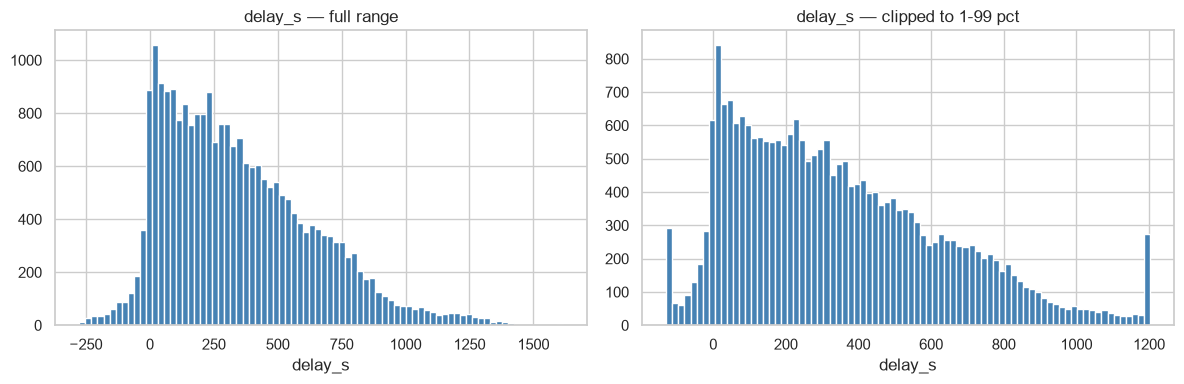

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[target], bins=80, color="steelblue")
axes[0].set_title(f"{target} — full range")
axes[0].set_xlabel(target)

lo_c, hi_c = df[target].quantile([0.01, 0.99])
clipped = df[target].clip(lo_c, hi_c)
axes[1].hist(clipped, bins=80, color="steelblue")
axes[1].set_title(f"{target} — clipped to 1-99 pct")
axes[1].set_xlabel(target)
plt.tight_layout()
plt.show()


C:\Users\danma\AppData\Local\Temp\ipykernel_30504\2220505181.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[target], vert=True)


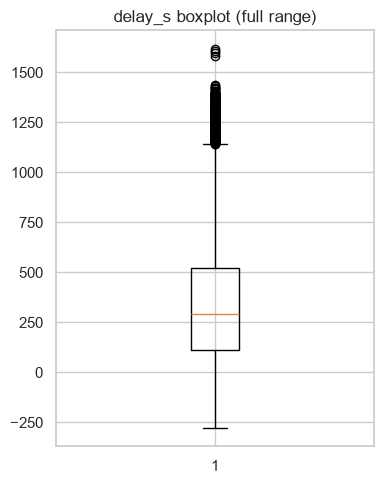

In [8]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(df[target], vert=True)
ax.set_title(f"{target} boxplot (full range)")
plt.tight_layout()
plt.show()


In [9]:
by_hour = df.groupby("hour")[target].agg(["mean", "median", "count"])
print("delay by hour:")
print(by_hour)


delay by hour:
            mean      median  count
hour                               
9      70.990506   63.505875     50
10    282.453884  266.527839    772
11    199.177854  115.535381   1410
12    304.483153  285.019484   2420
13    320.284283  265.066073   1427
14    288.548987  259.531136   2106
15    210.342377  176.013508   1059
16    426.746858  351.047414   4431
17    458.339525  411.055893   2660
18    309.480004  244.027111   2312
19    286.439192  268.013228   2251
20    439.252051  398.522722   2271
21    336.414379  303.018445    821
22      1.500672    1.500672      2


In [10]:
by_day = df.groupby("date")[target].agg(["mean", "median", "count"])
print("delay by day:")
print(by_day)


delay by day:
                  mean      median  count
date                                     
2026-03-09  269.095304  238.036184   7536
2026-03-10  379.375644  319.013001  16456


In [11]:
by_route = df.groupby("route_name")[target].agg(["mean", "median", "count"])
print("delay by route (single route in this dataset):")
print(by_route)


delay by route (single route in this dataset):
                  mean      median  count
route_name                               
Green       344.736071  292.030226  23992


## E4 — Target outliers (fences fit on TRAIN only; v2: dropped from TRAIN ONLY, test never filtered by label)

In [12]:
train_mask = df[schema["split_col"]] == "train"
test_mask = df[schema["split_col"]] == "test"

lo, hi = iqr_fences(df.loc[train_mask, target], k=3.0)
print(f"train-fit fences: lo={lo:.1f}  hi={hi:.1f}")

train_outliers = ((df.loc[train_mask, target] < lo) | (df.loc[train_mask, target] > hi)).sum()
test_outliers = ((df.loc[test_mask, target] < lo) | (df.loc[test_mask, target] > hi)).sum()
print(f"train outliers outside [lo, hi]: {train_outliers} / {train_mask.sum()}")
print(f"test rows outside [lo, hi] (reported only, NEVER dropped): {test_outliers} / {test_mask.sum()}")


train-fit fences: lo=-1221.1  hi=1936.1
train outliers outside [lo, hi]: 0 / 16456
test rows outside [lo, hi] (reported only, NEVER dropped): 0 / 7536


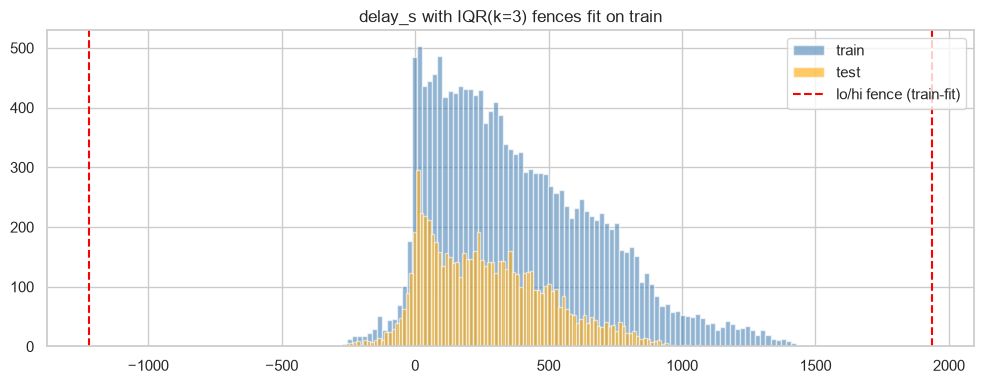

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df.loc[train_mask, target], bins=100, alpha=0.6, label="train", color="steelblue")
ax.hist(df.loc[test_mask, target], bins=100, alpha=0.6, label="test", color="orange")
ax.axvline(lo, color="red", linestyle="--", label="lo/hi fence (train-fit)")
ax.axvline(hi, color="red", linestyle="--")
ax.set_title(f"{target} with IQR(k=3) fences fit on train")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
# v2 rule: drop rows outside [lo, hi] from TRAIN ONLY. Test rows are NEVER filtered by
# their own label (that would flatter test metrics). Rationale: extreme *training* values
# are mostly label errors from missed arrival detections (approx one lap).
rows_before = len(df)
train_keep = train_mask & (df[target] >= lo) & (df[target] <= hi)
keep_mask = train_keep | test_mask
df_f = df.loc[keep_mask].reset_index(drop=True)
rows_after = len(df_f)

dropped_train = int(train_outliers)
print(f"rows before: {rows_before}  rows after: {rows_after}  dropped (train only): {rows_before - rows_after}")
print(f"train rows dropped: {dropped_train}  test rows dropped: 0 (test is never filtered by label)")
print(f"test rows outside fences but KEPT: {int(test_outliers)}")
assert (df_f[schema["split_col"]] == "test").sum() == int(test_mask.sum()), "test rows must all be kept"


rows before: 23992  rows after: 23992  dropped (train only): 0
train rows dropped: 0  test rows dropped: 0 (test is never filtered by label)
test rows outside fences but KEPT: 0


## E5 — Feature outliers (report only, no dropping)

In [15]:
train_f = df_f[df_f[schema["split_col"]] == "train"]
rows = []
for c in features:
    if not pd.api.types.is_numeric_dtype(train_f[c]):
        continue
    flo, fhi = iqr_fences(train_f[c], k=3.0)
    n_out = int(((train_f[c] < flo) | (train_f[c] > fhi)).sum())
    rows.append({"feature": c, "lo": flo, "hi": fhi, "n_outliers_train": n_out,
                 "pct_outliers_train": round(100 * n_out / len(train_f), 2)})
feat_outlier_tbl = pd.DataFrame(rows).sort_values("n_outliers_train", ascending=False)
feat_outlier_tbl


,feature,lo,hi,n_outliers_train,pct_outliers_train
31,wind_gust_mph,5.200000,25.500000,3094,18.80
28,rain_in,-0.012000,0.016000,2312,14.05
27,precip_in,-0.012000,0.016000,2312,14.05
32,precip_prev_1h,-0.012000,0.016000,2251,13.68
23,stop_planned_dwell_s,0.000000,0.000000,1495,9.08
11,stationary_s,-135.002112,180.002816,1464,8.90
18,tod_sin,-1.884127,0.241809,822,5.00
3,eta_frozen_polls,-12.000000,16.000000,563,3.42
12,stale_gps,0.000000,0.000000,533,3.24
1,eta_delta_s,-48.000000,36.000000,430,2.61


## E6 — Correlation (train only)

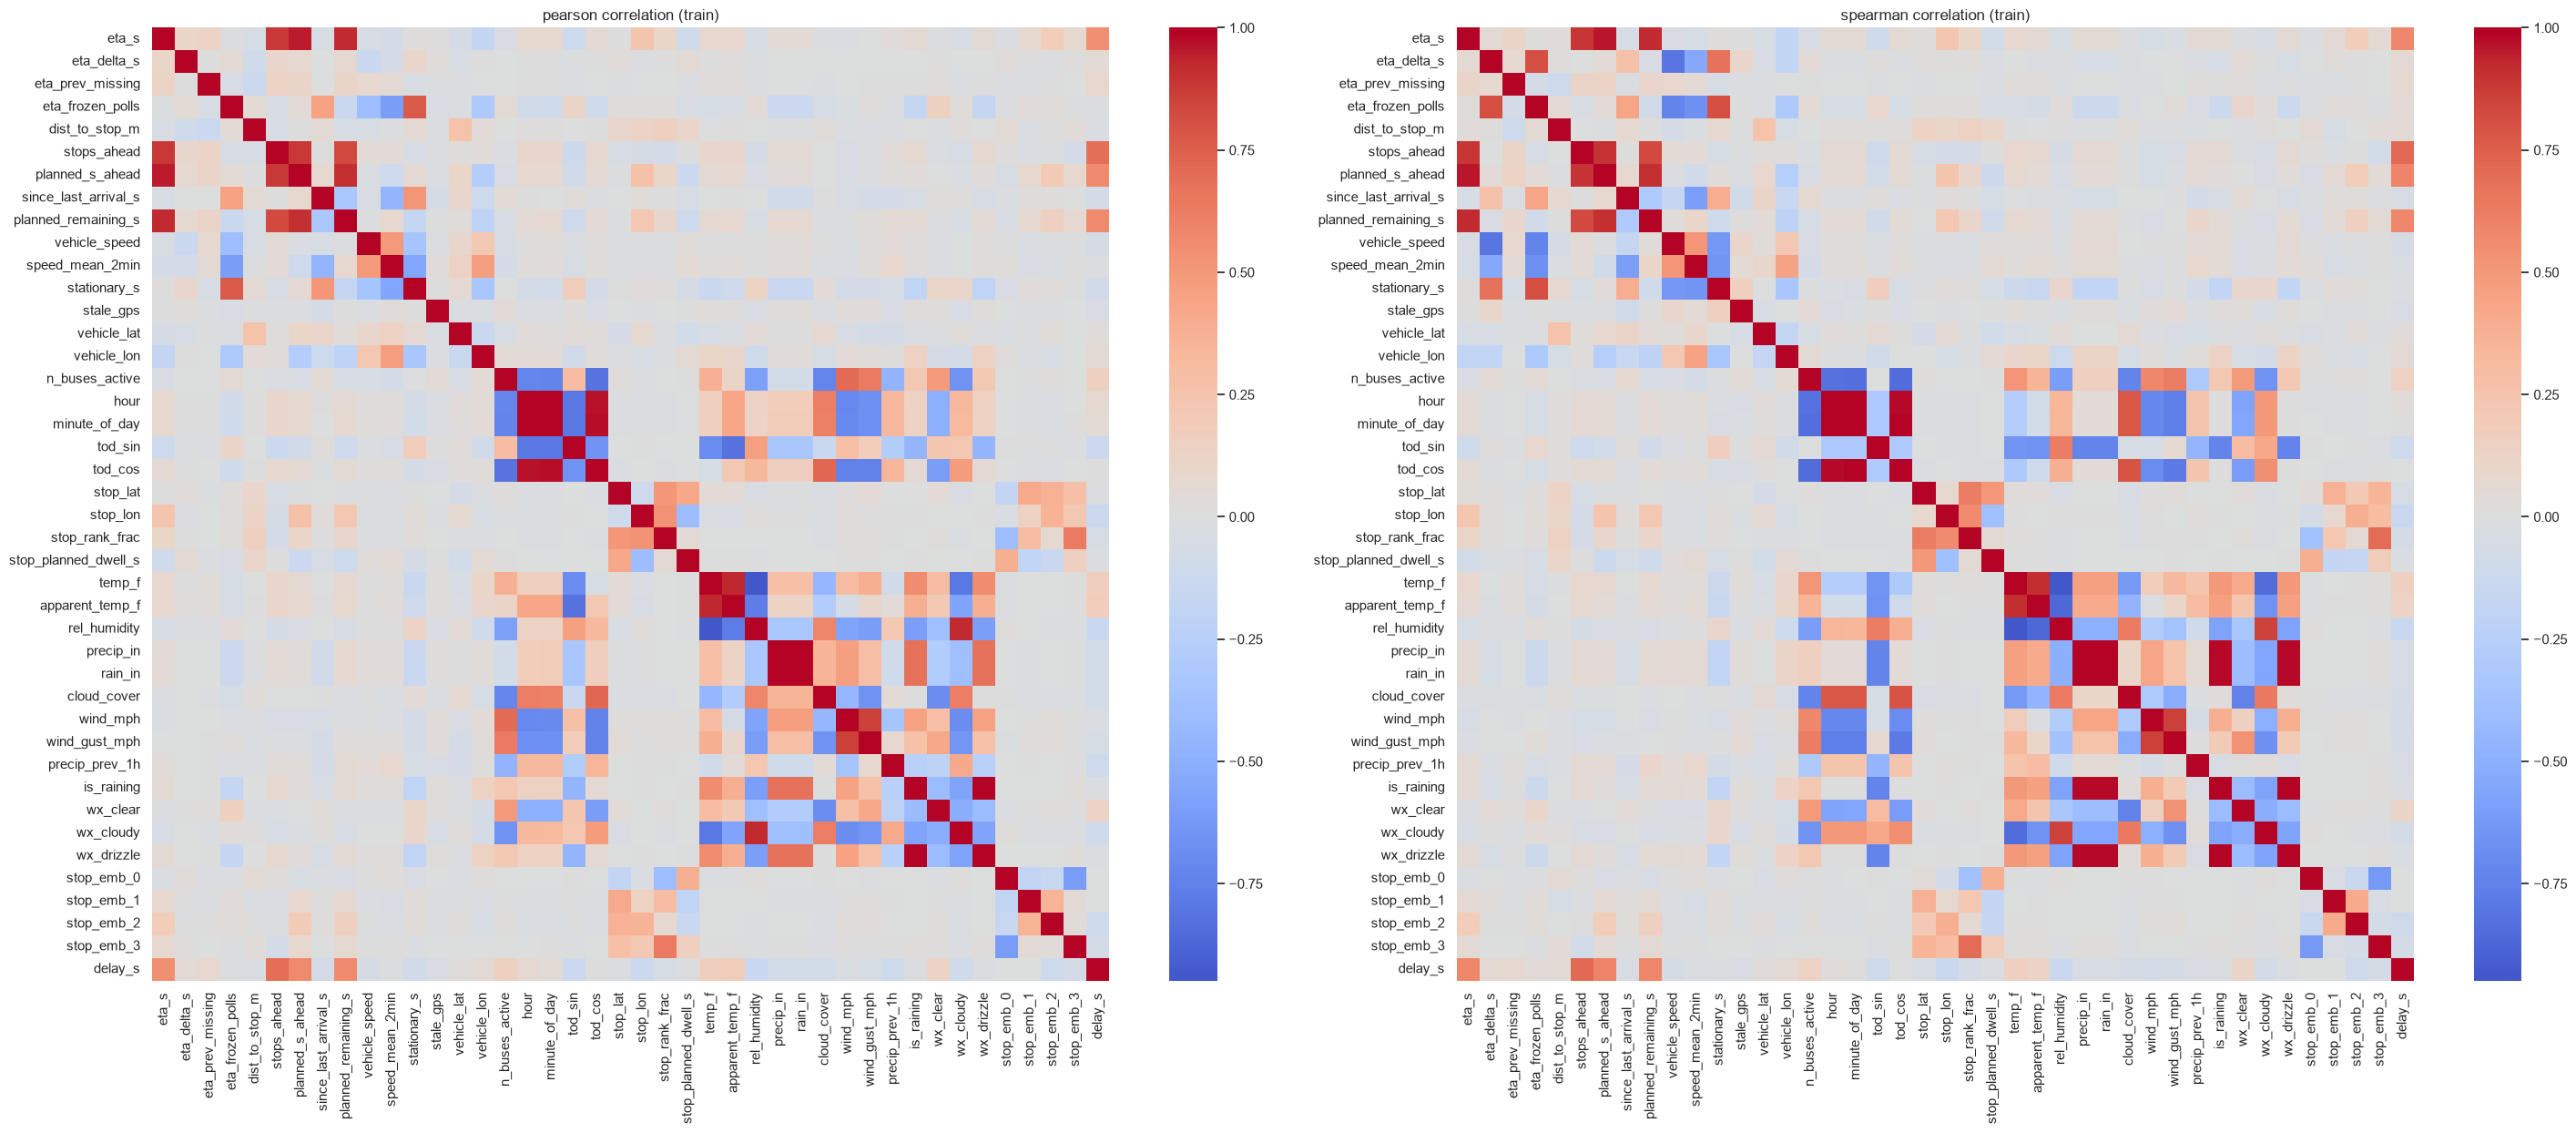

In [16]:
train_f_all = df_f[df_f[schema["split_col"]] == "train"]
corr_cols = features + [target]
n = len(corr_cols)
fig, axes = plt.subplots(1, 2, figsize=(max(14, n * 0.35) * 2, max(10, n * 0.3)))
for ax, method in zip(axes, ["pearson", "spearman"]):
    c = train_f_all[corr_cols].corr(method=method)
    sns.heatmap(c, cmap="coolwarm", center=0, ax=ax, cbar=True,
                xticklabels=True, yticklabels=True, square=False)
    ax.set_title(f"{method} correlation (train)")
plt.tight_layout()
plt.show()


In [17]:
top15_spearman = train_f_all[features].corrwith(train_f_all[target], method="spearman").abs().sort_values(ascending=False).head(15)
print("top 15 features by |spearman| with target:")
print(top15_spearman)


top 15 features by |spearman| with target:
stops_ahead            0.715777
planned_s_ahead        0.596415
planned_remaining_s    0.586162
eta_s                  0.577069
temp_f                 0.156808
rel_humidity           0.140666
n_buses_active         0.138440
stop_lon               0.134525
apparent_temp_f        0.124330
wx_clear               0.110575
tod_sin                0.107061
stop_emb_2             0.104122
wind_mph               0.077004
wx_cloudy              0.076630
eta_prev_missing       0.070497
dtype: float64


In [18]:
hc_spearman = high_corr_pairs(train_f_all, features, "spearman", 0.95)
print("high (>=0.95) spearman feature pairs:")
print(hc_spearman)


high (>=0.95) spearman feature pairs:
       feature_a        feature_b  spearman
9     is_raining       wx_drizzle  1.000000
4      precip_in          rain_in  1.000000
1           hour    minute_of_day  0.992945
3  minute_of_day          tod_cos  0.988753
7        rain_in       is_raining  0.982300
5      precip_in       is_raining  0.982300
8        rain_in       wx_drizzle  0.982300
6      precip_in       wx_drizzle  0.982300
2           hour          tod_cos  0.981624
0          eta_s  planned_s_ahead  0.957876


In [19]:
hc_pearson = high_corr_pairs(train_f_all, features, "pearson", 0.95)
print("high (>=0.95) pearson feature pairs:")
print(hc_pearson)


high (>=0.95) pearson feature pairs:


       feature_a        feature_b   pearson
4      precip_in          rain_in  1.000000
5     is_raining       wx_drizzle  1.000000
1           hour    minute_of_day  0.995718
3  minute_of_day          tod_cos  0.972939
2           hour          tod_cos  0.967989
0          eta_s  planned_s_ahead  0.953581


## E7 — Pruning (spearman, thresh=0.95, protect eta_s)

In [20]:
keep, dropped = prune_correlated(train_f_all, features, target, thresh=0.95, method="spearman")
print(f"kept {len(keep)} / {len(features)} features")
print("dropped:")
for d in dropped:
    print(d)


kept 35 / 41 features


dropped:
{'dropped': 'rain_in', 'kept': 'precip_in', 'spearman': 1.0, 'target_corr_dropped': 0.0418, 'target_corr_kept': 0.0418}
{'dropped': 'wx_drizzle', 'kept': 'is_raining', 'spearman': 1.0, 'target_corr_dropped': 0.0249, 'target_corr_kept': 0.0249}
{'dropped': 'minute_of_day', 'kept': 'hour', 'spearman': 0.9929, 'target_corr_dropped': 0.0071, 'target_corr_kept': 0.0282}
{'dropped': 'is_raining', 'kept': 'precip_in', 'spearman': 0.9823, 'target_corr_dropped': 0.0249, 'target_corr_kept': 0.0418}
{'dropped': 'tod_cos', 'kept': 'hour', 'spearman': 0.9816, 'target_corr_dropped': 0.0025, 'target_corr_kept': 0.0282}
{'dropped': 'planned_s_ahead', 'kept': 'eta_s', 'spearman': 0.9579, 'target_corr_dropped': 0.5964, 'target_corr_kept': 0.5771}


## E8 — Relationships

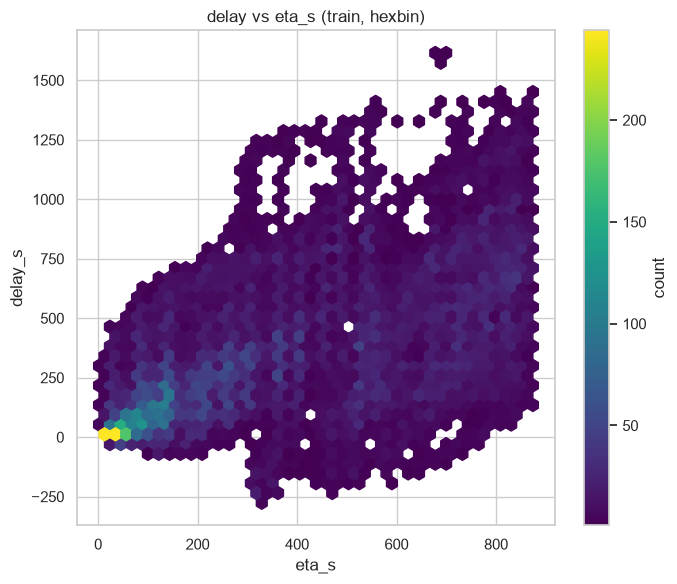

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
hb = ax.hexbin(train_f_all["eta_s"], train_f_all[target], gridsize=40, cmap="viridis", mincnt=1)
ax.set_xlabel("eta_s")
ax.set_ylabel(target)
ax.set_title("delay vs eta_s (train, hexbin)")
fig.colorbar(hb, ax=ax, label="count")
plt.tight_layout()
plt.show()


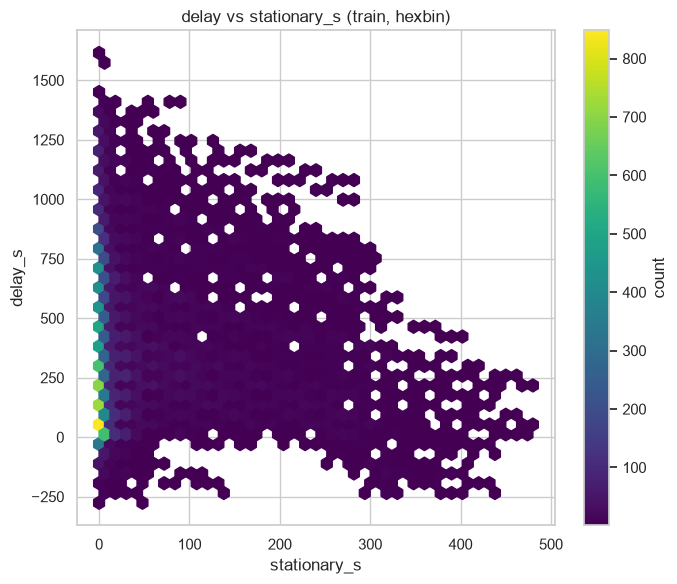

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
hb = ax.hexbin(train_f_all["stationary_s"], train_f_all[target], gridsize=40, cmap="viridis", mincnt=1)
ax.set_xlabel("stationary_s")
ax.set_ylabel(target)
ax.set_title("delay vs stationary_s (train, hexbin)")
fig.colorbar(hb, ax=ax, label="count")
plt.tight_layout()
plt.show()


weather group columns: ['wx_clear', 'wx_cloudy', 'wx_drizzle']
                  mean      median  count
wx_group                                 
wx_clear    443.874800  385.010340   4498
wx_cloudy   341.551409  299.035569   6738
wx_drizzle  372.621332  304.086781   5220


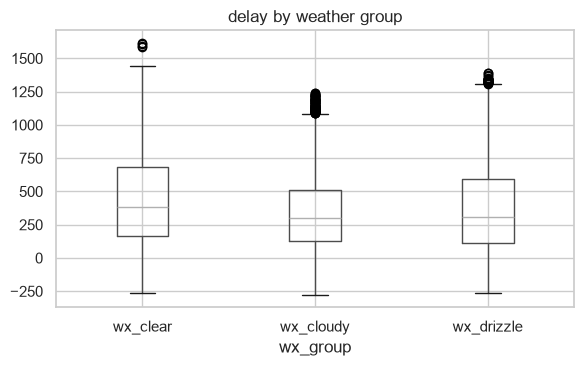

In [23]:
wx_cols = [c for c in features if c.startswith("wx_")]
print("weather group columns:", wx_cols)
wx_group = train_f_all[wx_cols].idxmax(axis=1) if wx_cols else None
if wx_group is not None:
    tmp = train_f_all.assign(wx_group=wx_group)
    print(tmp.groupby("wx_group")[target].agg(["mean", "median", "count"]))
    fig, ax = plt.subplots(figsize=(6, 4))
    tmp.boxplot(column=target, by="wx_group", ax=ax)
    ax.set_title("delay by weather group")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()


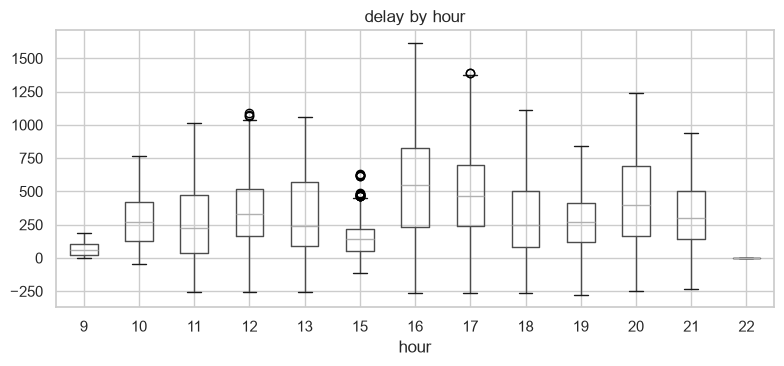

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
train_f_all.boxplot(column=target, by="hour", ax=ax)
ax.set_title("delay by hour")
plt.suptitle("")
plt.tight_layout()
plt.show()


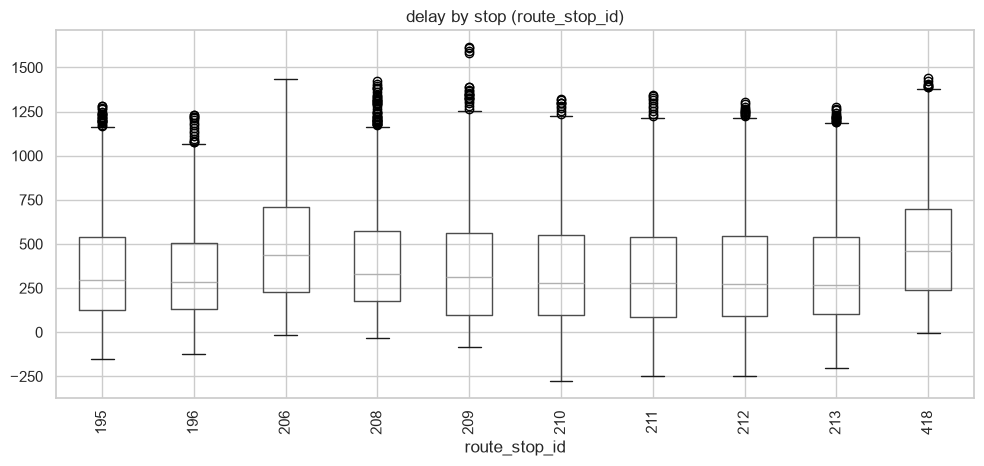

                     mean      median  count
route_stop_id                               
195            357.453275  293.027379   1677
196            340.446242  286.029950   1609
206            475.776489  438.023779   1745
208            400.039172  329.013711   1527
209            367.767832  312.012587   1495
210            331.556360  277.009321   1663
211            334.847901  276.504269   1688
212            345.385947  270.820210   1660
213            342.754576  267.013137   1665
418            488.851901  458.026668   1727


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
train_f_all.boxplot(column=target, by="route_stop_id", ax=ax, rot=90)
ax.set_title("delay by stop (route_stop_id)")
plt.suptitle("")
plt.tight_layout()
plt.show()
print(train_f_all.groupby("route_stop_id")[target].agg(["mean", "median", "count"]))


## E9 — Save model-ready dataset (v2: constants checked within TRAIN split)

In [26]:
# v2: a feature could be non-constant overall but constant within the (filtered) train
# split alone -- check train only, and drop any offenders before saving.
newly_constant_train = [c for c in keep if train_f_all[c].nunique(dropna=False) <= 1]
print("features constant within train after the outlier filter:", newly_constant_train)
final_features = [c for c in keep if c not in newly_constant_train]

notes = {
    "outlier_rule": "IQR(k=3) fences fit on TRAIN target only; rows outside fences dropped from TRAIN ONLY; test rows are never filtered by their label",
    "target_fences": {"lo": lo, "hi": hi},
    "rows_before": rows_before,
    "rows_after": rows_after,
    "dropped_train": dropped_train,
    "test_rows_outside_fences_kept": int(test_outliers),
    "correlation_pruning": {"method": "spearman", "thresh": 0.95, "protect": ["eta_s"], "dropped": dropped},
    "newly_constant_in_train_dropped": newly_constant_train,
}
out = save_model_ready(DS, df_f, final_features, notes=notes)
print("saved model-ready shape:", out.shape)


features constant within train after the outlier filter: []
saved model-ready shape: (23992, 44)


In [27]:
mr = load_model_ready(DS)
assert mr.df[mr.features + [mr.target]].isna().sum().sum() == 0, "nulls after save"
train_const_after = [c for c in mr.features if mr.X_train[c].nunique() <= 1]
print("features constant within train after reload:", train_const_after)
assert not train_const_after, f"constant-in-train features present: {train_const_after}"
print("train rows:", len(mr.X_train), "test rows:", len(mr.X_test))
assert len(mr.X_train) > 0 and len(mr.X_test) > 0
assert len(mr.X_test) == int(test_mask.sum()), "every test row from the features parquet must be kept"
print("OK: 0 nulls, 0 features constant within train, both splits non-empty, all test rows kept")


features constant within train after reload: []
train rows: 16456 test rows: 7536
OK: 0 nulls, 0 features constant within train, both splits non-empty, all test rows kept


## E10 — Findings

- **Single bus, whole-day v2 split.** All 23,992 rows are vehicle 3 on the Green (17) route. Under the v2 whole-service-day split, train is entirely 2026-03-10 (16,456 rows, 68.6%) and test is entirely 2026-03-09 (7,536 rows, 31.4%) — no hour-block leakage across the split. `cv_group` breaks each day into 3-hour blocks: 5 groups in train, 3 in test.
- **Build now drops stale-ETA rows.** Rows where TransLoc's ETA still points at the stop the bus just passed (a stale next-stop reading, or an ETA under 2 minutes while sitting at that stop) are dropped before labeling — for the full Green route this removed 1,665 rows upstream of the single-vehicle/day filter that produces this dataset.
- **Clean data.** 0 nulls across 41 features + target, 0 exact duplicate rows, 0 constant features before filtering.
- **Target is right-skewed, mostly positive delay.** `delay_s`: mean 344.7s, median 292.0s, std 292.4s, skew 0.81, kurtosis 0.36, range [-276.0, 1615.1]s — buses run late far more often than early.
- **The day-based split carries a real distribution shift.** Test day 2026-03-09 ran noticeably less delayed than train day 2026-03-10: mean 269.1s vs 379.4s (medians 238.0s vs 319.0s). A model fit only on 03-10 has to generalize across this day-to-day shift — exactly the kind of gap the old date_hour split hid by mixing train/test rows within the same service day.
- **Test day also carries a covariate shift, not just a label shift.** On 03-09 (test), `n_buses_active` is constant at 2, and `precip_in`/`precip_prev_1h` are constant at 0.0 for every row — all three vary only within train (`n_buses_active` in {1, 2}; `precip_in`/`precip_prev_1h` up to 0.039 in/hr). A model can't learn anything from these columns that transfers to test — on 03-09 they're present but uninformative.
- **No target outliers under the v2 rule.** Train-fit IQR(k=3) fences on `delay_s`: [-1221.1, 1936.1]s. 0/16,456 train rows and 0/7,536 test rows fall outside — nothing was dropped (rows before/after: 23,992 -> 23,992); test rows are never filtered by their own label regardless.
- **Feature outliers concentrate in weather/state indicators**, not the ETA signal: `wind_gust_mph` (3,094/16,456 train rows flagged, 18.80%), `rain_in`/`precip_in` (2,312 each, 14.05%), `precip_prev_1h` (2,251, 13.68%), `stop_planned_dwell_s` (1,495, 9.08%) — reported per spec, not dropped.
- **Trip-progress features dominate the target correlation**; weather/time-of-day are weak secondary signals: top |spearman| with `delay_s` are `stops_ahead` (0.716), `planned_s_ahead` (0.596), `planned_remaining_s` (0.586), `eta_s` (0.577), then a drop to `temp_f` (0.157).
- **Correlation pruning removed 6 of 41 features** (35 kept) at spearman >=0.95 on train: `rain_in` dropped for `precip_in` (corr 1.0) and `wx_drizzle` dropped for `is_raining` (corr 1.0); `is_raining` was then itself dropped for `precip_in` (corr 0.982) — so despite being a keeper in that first pass, `is_raining` does NOT survive pruning, only `precip_in` does; `minute_of_day` (corr 0.993) and `tod_cos` (corr 0.982) both dropped for `hour`; and `planned_s_ahead` dropped for the protected `eta_s` (corr 0.958) even though `planned_s_ahead` had the slightly higher raw target correlation (0.596 vs 0.577) — the `eta_s` protection rule wins regardless. The 6 dropped features, matching the E7 output and the model-ready schema exactly: `rain_in`, `wx_drizzle`, `minute_of_day`, `is_raining`, `tod_cos`, `planned_s_ahead`.
- **Weather and stop effects are present but modest and likely confounded.** Mean delay by weather group: `wx_clear` 443.9s (n=4,498), `wx_drizzle` 372.6s (n=5,220), `wx_cloudy` 341.6s (n=6,738) — clear weather is *highest*, not lowest, which for a single bus over a single train day is more likely traffic/time-of-day confounding than a causal weather effect. Stop-level delay varies ~157s across the route's 10 stops, from 331.6s mean (stop 210) to 488.9s mean (stop 418).
- **Final model-ready dataset:** 23,992 rows (35 features + target + 8 meta cols = 44 columns) saved via `save_model_ready`; reload confirms 0 nulls, 0 features constant within the train split, train 16,456 / test 7,536 rows — matching the features parquet split exactly, so no test row was ever dropped.